# Analisis Sentimen Pelanggan UMKM

## Pendahuluan
Pada notebook ini, kita akan membangun model prediksi untuk analisis sentimen pelanggan menggunakan teknik machine learning. Model ini akan membantu UMKM memahami sentimen positif, negatif, atau netral dari ulasan pelanggan mereka.

## Langkah 1: Memuat Dataset
Pada langkah ini, kita akan memuat dataset yang berisi teks ulasan pelanggan dan rating yang diberikan. Data ini akan digunakan untuk melatih model analisis sentimen berbasis AI.

In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('8_sentimen_pelanggan.xlsx')
dummy_df


,Review Text,Rating
0,"Produk ini sangat bagus, kualitas luar biasa",1
1,"Tidak puas dengan produk ini, kecewa sekali",1
2,Pelayanan cepat dan produk berkualitas,2
3,"Tidak puas dengan produk ini, kecewa sekali",2
4,"Tidak puas dengan produk ini, kecewa sekali",2
...,...,...
295,"Produk cukup oke, tapi harganya terlalu mahal",3
296,"Kualitas produk sesuai dengan harga, puas",1
297,"Sangat puas, pelayanan ramah dan cepat",2
298,"Tidak direkomendasikan, kualitas buruk",1


## Langkah 2: Visualisasi Data
Setelah memuat dataset, kita akan melihat distribusi rating pelanggan untuk memahami keseimbangan antara sentimen positif, negatif, dan netral dalam data.

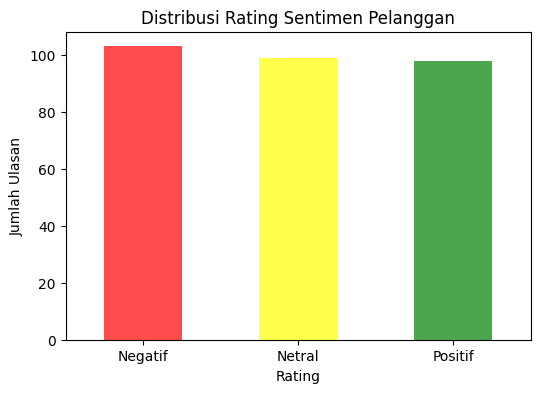

In [ ]:

import matplotlib.pyplot as plt

# Plotting the distribution of ratings (1 = Negative, 2 = Neutral, 3 = Positive)
plt.figure(figsize=(6, 4))
dummy_df['Rating'].value_counts().plot(kind='bar', color=['red', 'yellow', 'green'], alpha=0.7)
plt.title("Distribusi Rating Sentimen Pelanggan")
plt.xlabel("Rating")
plt.ylabel("Jumlah Ulasan")
plt.xticks([0, 1, 2], ['Negatif', 'Netral', 'Positif'], rotation=0)
plt.show()


## Langkah 3: Preprocessing Data
Pada langkah ini, kita akan memproses data ulasan untuk mengubah teks menjadi format yang dapat dipahami oleh model machine learning, yaitu menggunakan teknik vectorization.

In [ ]:
!pip install nltk Sastrawi
import nltk
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
# Download Indonesian stopwords if not already downloaded
nltk.download('punkt') # This is needed for word tokenization
# Create a stop word remover object
factory = StopWordRemoverFactory()
#stopword = factory.create_stop_word_remover() # This line is not needed and was causing the error.

# Get the list of Indonesian stop words from Sastrawi
stop_words_indonesian = factory.get_stop_words() # Access get_stop_words through the factory instance

# Vectorizing the review text using TF-IDF with Indonesian stop words
vectorizer = TfidfVectorizer(stop_words=stop_words_indonesian, max_features=1000)  # Use Indonesian stop words
X = vectorizer.fit_transform(dummy_df["Review Text"])

# Target variable (Rating)
y = dummy_df["Rating"]

# Show the shape of the transformed data
X.shape

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


(300, 29)

## Langkah 4: Pembagian Data Train dan Test
Setelah preprocessing, kita akan membagi dataset menjadi dua bagian: satu untuk pelatihan model (train) dan satu lagi untuk menguji akurasi model (test). Pembagian ini penting untuk mengevaluasi kinerja model.

In [ ]:
from sklearn.model_selection import train_test_split
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Display the shape of the train and test sets
X_train.shape, X_test.shape


((210, 29), (90, 29))

## Langkah 5: Melatih Model
Pada langkah ini, kita akan melatih model menggunakan algoritma Naive Bayes yang banyak digunakan dalam analisis teks, khususnya untuk klasifikasi sentimen.

In [ ]:

from sklearn.naive_bayes import MultinomialNB

# Train a Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Check the accuracy on the training data
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

train_accuracy, test_accuracy


(0.42857142857142855, 0.2777777777777778)

## Langkah 6: Evaluasi Model
Setelah melatih model, kita akan mengevaluasi kinerjanya menggunakan metrik seperti akurasi dan laporan klasifikasi untuk mengetahui seberapa baik model dalam mengklasifikasikan sentimen.

In [ ]:
from sklearn.metrics import classification_report
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
classification_report(y_test, y_pred)


'              precision    recall  f1-score   support\n\n           1       0.28      0.68      0.40        22\n           2       0.14      0.03      0.05        35\n           3       0.30      0.27      0.29        33\n\n    accuracy                           0.28        90\n   macro avg       0.24      0.33      0.24        90\nweighted avg       0.23      0.28      0.22        90\n'

## Langkah 7: Prediksi
Setelah model dilatih, kita dapat menggunakannya untuk memprediksi sentimen pelanggan terhadap ulasan baru berdasarkan teks ulasan tersebut.

In [ ]:

# Example prediction for a new review
new_review = ["Produk ini sangat memuaskan, kualitas terbaik yang pernah saya beli."]
new_review_vectorized = vectorizer.transform(new_review)

# Predict sentiment
sentiment_prediction = model.predict(new_review_vectorized)
sentiment_prediction


array([1])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
